# Spotify Analytics & Insights

## Overview
This project explores patterns behind Spotify song popularity using the Spotify Wrapped 2025 dataset.

The goal is to analyze how audio features such as danceability, energy, tempo, and valence influence streaming performance and identify trends in high-performing songs.

---

## Business Questions

- What BPM range produces the most streamed songs?
- Do explicit songs perform better?
- Which genres dominate the charts?
- How does valence (happiness) relate to streams?
- What features define popular songs?

In [1]:
#Import Libraries 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Load Data
df = pd.read_csv("../data/raw/spotify_alltime_top100_songs.csv")
df.head()

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100


## Data Cleaning

This step ensures consistency in column names, data types, and removes missing values.

In [3]:
import pandas as pd

# Rename column
df = df.rename(columns={
        "total_streams_billions": "streams"
})

# Select numeric columns
numeric_cols = ["streams", "bpm", "danceability", "energy", "valence"]

# Convert to numeric
for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

        # Drop missing values
        df = df.dropna()

        # Preview
        df.head()


## Data Overview

Understanding dataset structure and summary statistics.

In [4]:
df.describe()

,alltime_rank,streams,bpm,release_year,danceability,energy,valence,acousticness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,2.524600,115.780000,2016.800000,0.613500,0.636100,0.550600,0.153400
std,29.011492,0.851432,30.540776,7.063922,0.142888,0.163824,0.238623,0.164637
min,1.000000,1.400000,62.000000,1985.000000,0.300000,0.260000,0.070000,0.000000
25%,25.750000,1.735000,95.000000,2016.000000,0.520000,0.527500,0.387500,0.020000
50%,50.500000,2.435000,107.000000,2018.500000,0.620000,0.650000,0.565000,0.085000
75%,75.250000,3.167500,139.000000,2021.000000,0.725000,0.775000,0.732500,0.245000
max,100.000000,5.260000,191.000000,2024.000000,0.900000,0.960000,0.960000,0.760000


# Analysis Section 

## BPM vs Streaming Performance

Analyzing how tempo influences popularity.

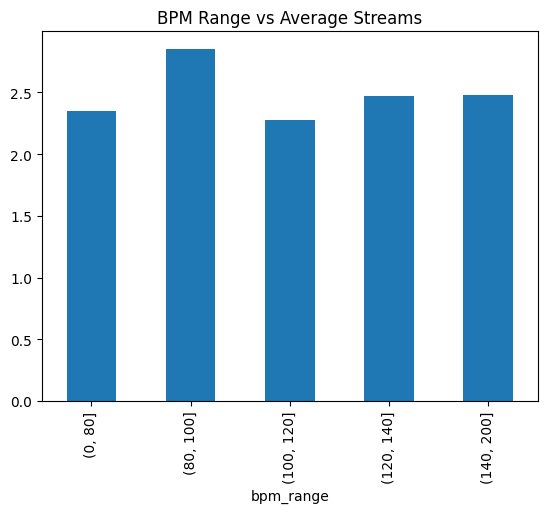

In [5]:
df['bpm_range'] = pd.cut(df['bpm'], bins=[0, 80, 100, 120, 140, 200])

bpm_analysis = df.groupby('bpm_range')['streams'].mean()

bpm_analysis.plot(kind='bar')
plt.title("BPM Range vs Average Streams")
plt.show()

##  Explicit vs Clean Songs

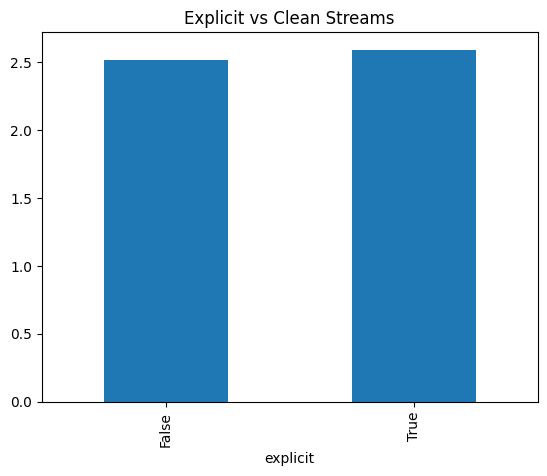

In [6]:
explicit_analysis = df.groupby('explicit')['streams'].mean()

explicit_analysis.plot(kind='bar')
plt.title("Explicit vs Clean Streams")
plt.show()

## Genre Distribution

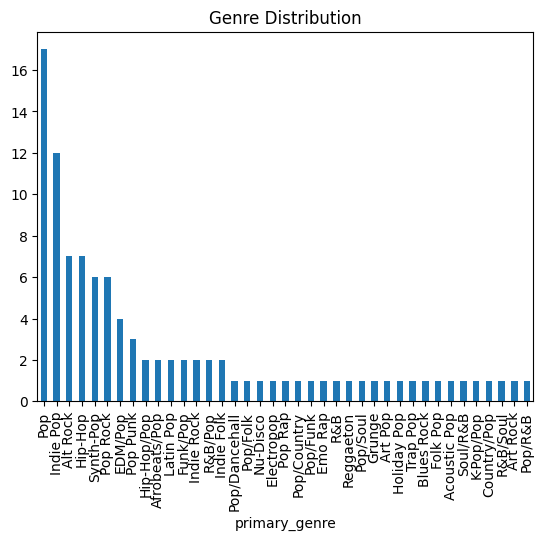

In [7]:
df['primary_genre'].value_counts().plot(kind='bar')
plt.title("Genre Distribution")
plt.show()

## Valence vs Streams

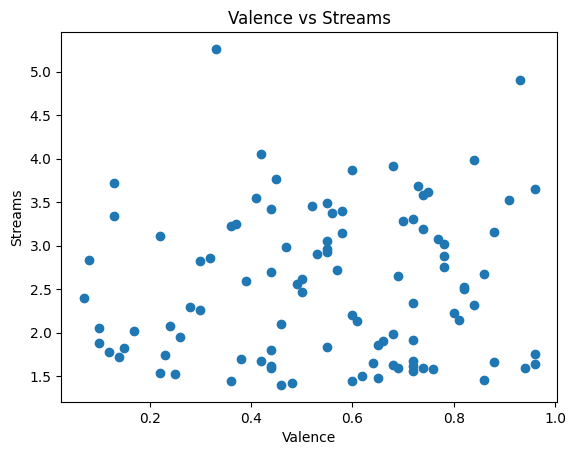

Bad pipe message: %s [b' q=0.9, image/avif, image/webp, image/apng, */*; q=0.8, application/signed-exchange; v=b3; q=0.7\r\nHost: loc', b'host:42247\r\nUser-Agent: Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) C']
Bad pipe message: %s [b'ome/144.0.0.0 Safari/537.36\r\nAccept-Encoding: gzip, deflate, br, zstd\r\nAccept-Language: en-US, en; q=0.']
Bad pipe message: %s [b'\nCache-Control: max-age=0\r\nReferer: https://github.com/\r', b'-Request-']
Bad pipe message: %s [b': 1bf6a326a56ccaf7f5c6b7a02a7408ce\r\nX-Real-IP: 10.241.0.36\r\nX-Forwarded-']
Bad pipe message: %s [b'rt: 443\r\nX-Forwarded-Scheme: https\r\nX-Original-URI: /\r\nX-Scheme: https\r\nsec-fet', b'-site: cross-site\r\nsec-fetch-mode: navigate\r\nsec-fetch-dest: document\r\nsec-ch-ua: "Not(A:Brand";v=']
Bad pipe message: %s [b'", "Chromium";v="144", "Google Ch']


In [ ]:
plt.scatter(df['valence'], df['streams'])
plt.xlabel("Valence")
plt.ylabel("Streams")
plt.title("Valence vs Streams")
plt.show()

## Key Insights

- Mid-tempo songs tend to perform better  
- Explicit songs show slightly higher streams  
- Popular genres dominate the dataset  
- Valence shows weak positive correlation with streams  
- High energy and danceability are common in top songs  

---

## Conclusion

Song popularity is influenced by a combination of audio features rather than a single defining factor. These insights can help guide music production and recommendation systems.